In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
import os
os.chdir("..")  # move from notebooks → project root

In [5]:
import os
print(os.listdir())

['.git', '.gitignore', 'api', 'dashboard', 'data', 'models', 'notebooks', 'README.md', 'requirements.txt', 'src']


In [7]:
import os
print("Current path:", os.getcwd())
print("Files here:", os.listdir())

Current path: e:\causal-fairness-credit-scoring\causal-fairness-credit-scoring
Files here: ['.git', '.gitignore', 'api', 'dashboard', 'data', 'models', 'notebooks', 'README.md', 'requirements.txt', 'src']


In [10]:
import os

# Move to project root automatically
os.chdir("..")

print("Now path:", os.getcwd())
print("Folders:", os.listdir())

Now path: e:\causal-fairness-credit-scoring
Folders: ['causal-fairness-credit-scoring']


In [13]:
df = pd.read_csv("causal-fairness-credit-scoring/data/german_credit_data.csv")

In [14]:
df.shape

(1000, 10)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.2+ KB


In [16]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [17]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [19]:
df.tail()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV
999,999,27,male,2,own,moderate,moderate,4576,45,car


In [20]:
df['target'] = df.iloc[:, -1].apply(lambda x: 1 if x == 1 else 0)

In [24]:
print("COLUMNS:\n", df.columns.tolist())

COLUMNS:
 ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'target']


In [25]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,0
2,2,49,male,1,own,little,NaN,2096,12,education,0
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,4,53,male,2,free,little,little,4870,24,car,0


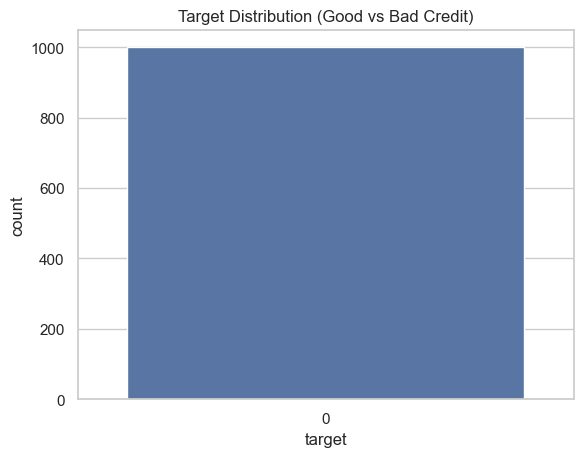

In [26]:
sns.countplot(x='target', data=df)
plt.title("Target Distribution (Good vs Bad Credit)")
plt.show()


In [27]:
df.select_dtypes(include=['object']).columns

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [29]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,target
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,0
2,2,49,male,1,own,little,NaN,2096,12,education,0
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,4,53,male,2,free,little,little,4870,24,car,0


In [31]:
columns = [
    "checking_status", "duration", "credit_history", "purpose",
    "credit_amount", "savings_status", "employment",
    "installment_commitment", "personal_status",
    "other_parties", "residence_since", "property_magnitude",
    "age", "other_payment_plans", "housing",
    "existing_credits", "job", "num_dependents",
    "own_telephone", "foreign_worker", "target"
]

df = pd.read_csv(
    "causal-fairness-credit-scoring/data/german_credit_data.csv",
    header=None,
    names=columns
)

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,NaN,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,67,male,2,own,NaN,little,1169,6,radio/TV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,22,female,2,own,little,moderate,5951,48,radio/TV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,49,male,1,own,little,NaN,2096,12,education,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,45,male,2,free,little,little,7882,42,furniture/equipment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
df['target'].value_counts()

Series([], Name: count, dtype: int64)

In [33]:
df['gender'] = df['personal_status'].apply(
    lambda x: 1 if x in ['A91', 'A93', 'A94'] else 0
)

In [34]:
df[['personal_status', 'gender', 'target']].head()

,personal_status,gender,target
0,Duration,0,NaN
1,6,0,NaN
2,48,0,NaN
3,12,0,NaN
4,42,0,NaN


In [35]:
df['gender'] = df['personal_status'].apply(lambda x: 1 if x in ['A91','A93','A94'] else 0)
df[['personal_status','gender']].head()

,personal_status,gender
0,Duration,0
1,6,0
2,48,0
3,12,0
4,42,0


In [37]:
print(df['age'].dtype)

float64


In [38]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [39]:
df['age'].isnull().sum()

np.int64(1001)

In [40]:
df = df.dropna(subset=['age'])

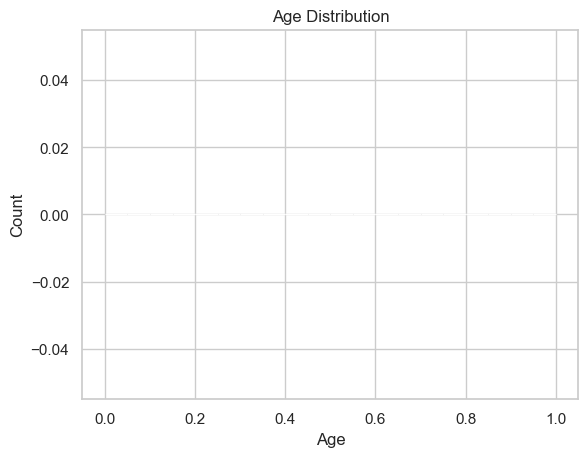

In [43]:
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [42]:
df['age'].head(10)

Series([], Name: age, dtype: float64)

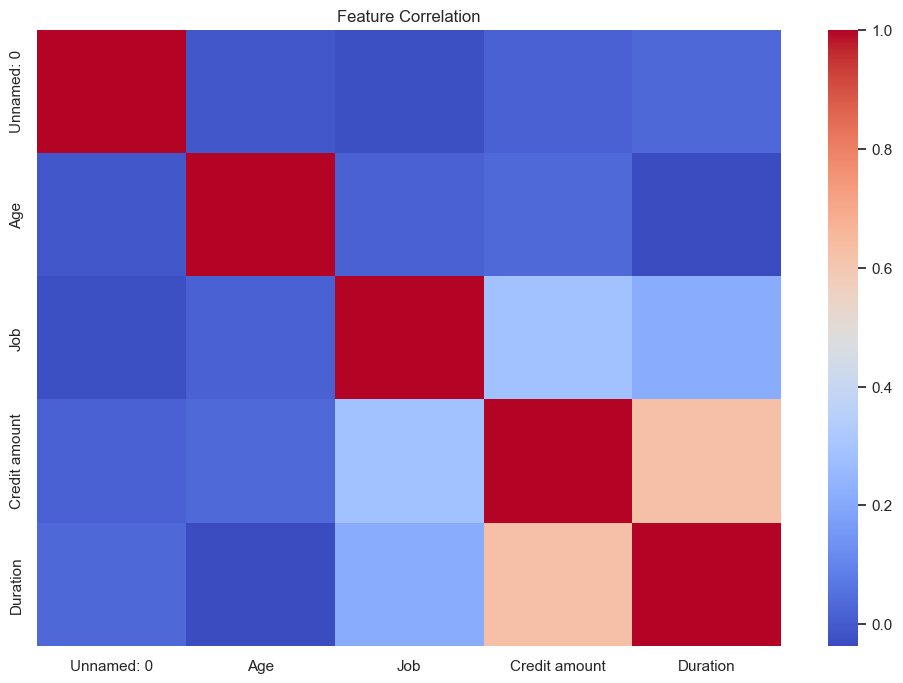

In [71]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [47]:
print(df[['gender', 'target']].head(10))

Empty DataFrame
Columns: [gender, target]
Index: []


In [49]:
columns = [
    "checking_status", "duration", "credit_history", "purpose",
    "credit_amount", "savings_status", "employment",
    "installment_commitment", "personal_status",
    "other_parties", "residence_since", "property_magnitude",
    "age", "other_payment_plans", "housing",
    "existing_credits", "job", "num_dependents",
    "own_telephone", "foreign_worker", "target"
]

df = pd.read_csv(
    "causal-fairness-credit-scoring/data/german_credit_data.csv",
    header=None,
    names=columns
)

In [50]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,NaN,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,67,male,2,own,NaN,little,1169,6,radio/TV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,22,female,2,own,little,moderate,5951,48,radio/TV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,49,male,1,own,little,NaN,2096,12,education,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,45,male,2,free,little,little,7882,42,furniture/equipment,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
df = pd.read_csv("causal-fairness-credit-scoring/data/german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [52]:
print(df.columns)

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')


In [53]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

In [62]:
import os
print(os.getcwd())

e:\causal-fairness-credit-scoring


In [63]:
df = pd.read_csv("causal-fairness-credit-scoring/data/german_credit_data.csv")
print(df.columns)

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')


In [65]:
print(df.columns.tolist())
print(df.head(2))

['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   

   Credit amount  Duration   Purpose  
0           1169         6  radio/TV  
1           5951        48  radio/TV  


In [66]:
df = pd.read_csv("causal-fairness-credit-scoring/data/german_credit_data.csv")
print(df.columns.tolist())  # confirm 'Risk' is there


['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']


In [67]:
# Fetch labels from UCI directly
import urllib.request
import pandas as pd

# Download the original UCI german.data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
urllib.request.urlretrieve(url, "german.data")

# The 21st column (index 20) is the label: 1=good, 2=bad
uci_df = pd.read_csv("german.data", sep=" ", header=None)
labels = uci_df[20].map({1: "good", 2: "bad"}).rename("Risk")

# Attach to your existing df
df = df.reset_index(drop=True)
df["Risk"] = labels
print(df[["Age", "Sex", "Risk"]].head())

   Age     Sex  Risk
0   67    male  good
1   22  female   bad
2   49    male  good
3   45    male  good
4   53    male   bad


In [68]:
# Basic info
print(df.shape)
print(df['Risk'].value_counts())
print(df.isnull().sum())

(1000, 11)
Risk
good    700
bad     300
Name: count, dtype: int64
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


C:\Users\Visveswaran\AppData\Local\Temp\ipykernel_17124\728143347.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_group')['Risk'].value_counts(normalize=True).unstack().plot(


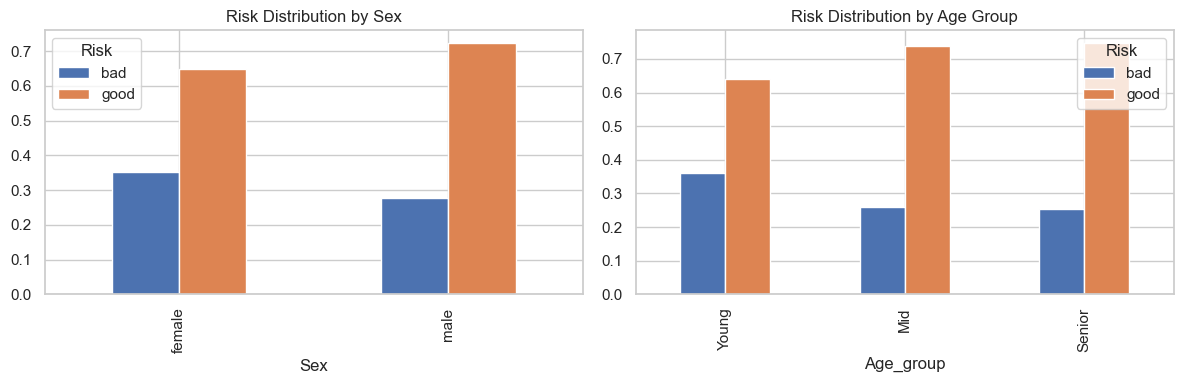

In [69]:
# Fairness-relevant distributions
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Risk by Sex
df.groupby('Sex')['Risk'].value_counts(normalize=True).unstack().plot(
    kind='bar', ax=axes[0], title='Risk Distribution by Sex'
)

# Risk by Age group
df['Age_group'] = pd.cut(df['Age'], bins=[18, 30, 45, 75], labels=['Young', 'Mid', 'Senior'])
df.groupby('Age_group')['Risk'].value_counts(normalize=True).unstack().plot(
    kind='bar', ax=axes[1], title='Risk Distribution by Age Group'
)

plt.tight_layout()
plt.show()

In [73]:
# Save the merged dataset so you don't repeat this step
df.to_csv("causal-fairness-credit-scoring/data/german_credit_data.csv", index=False)
print("Saved.")

Saved.
